# Multiscale entropy with Approximate Entropy and Sample Entropy

This notebook extends the original Approximate Entropy work in an important direction:
instead of measuring regularity at a single resolution, we measure it across several
time scales.

That matters because a signal may look noisy at a fine scale and highly structured at a
coarser scale, or the reverse. In physiology, telemetry, energy, and industrial sensor
systems, that difference is often the real story.

## What multiscale entropy does

The idea is simple.

1. **Coarse-grain** the series at scale `τ`.
   - At scale 1, the series is unchanged.
   - At scale 2, average adjacent pairs.
   - At scale 3, average adjacent triplets.
   - And so on.
2. Compute an entropy measure on each coarse-grained series.
3. Study how regularity changes with scale.

In the literature, multiscale entropy is often paired with **Sample Entropy** because it
avoids some of the finite-sample bias of ApEn. Here we compute both when useful, but we
keep ApEn in the loop because it is the core object of this notebook suite.

In [1]:
from __future__ import annotations

from typing import Iterable, Sequence
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["figure.figsize"] = (10, 4)


def to_1d_float_array(x: Sequence[float] | np.ndarray, *, name: str = "x") -> np.ndarray:
    """Validate and convert input to a 1D float NumPy array."""
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, got shape={arr.shape}.")
    if arr.size == 0:
        raise ValueError(f"{name} must contain at least one value.")
    if not np.isfinite(arr).all():
        raise ValueError(f"{name} contains NaN or infinite values.")
    return arr


def embed(series: Sequence[float] | np.ndarray, m: int) -> np.ndarray:
    """Return the delay-embedding matrix with lag 1 and dimension m."""
    x = to_1d_float_array(series)
    if not isinstance(m, int) or m < 1:
        raise ValueError("m must be a positive integer.")
    n = x.size
    if n <= m:
        raise ValueError(f"Need len(series) > m, got n={n}, m={m}.")
    return np.lib.stride_tricks.sliding_window_view(x, m)


def phi(series: Sequence[float] | np.ndarray, m: int, r: float) -> float:
    """Compute the ApEn phi_m quantity using the Chebyshev distance."""
    x = to_1d_float_array(series)
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    patterns = embed(x, m)
    # Pairwise Chebyshev distance between all embedded vectors.
    distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
    c_i = np.mean(distances <= r, axis=1)
    c_i = np.clip(c_i, 1e-12, None)
    return float(np.mean(np.log(c_i)))


def approximate_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Approximate Entropy (ApEn).

    Parameters
    ----------
    series:
        Input time series.
    m:
        Embedding dimension.
    r:
        Tolerance. If omitted, uses 0.2 * standard deviation of the series.
    """
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    return phi(x, m, r) - phi(x, m + 1, r)


def sample_entropy(series: Sequence[float] | np.ndarray, m: int = 2, r: float | None = None) -> float:
    """Sample Entropy (SampEn) with Chebyshev distance."""
    x = to_1d_float_array(series)
    if r is None:
        std = float(np.std(x, ddof=0))
        r = 0.2 * std if std > 0 else 0.2
    if not np.isfinite(r) or r <= 0:
        raise ValueError("r must be a positive finite number.")

    def _count_matches(patterns: np.ndarray) -> float:
        distances = np.max(np.abs(patterns[:, None, :] - patterns[None, :, :]), axis=2)
        matches = (distances <= r).astype(float)
        np.fill_diagonal(matches, 0.0)
        return float(matches.sum())

    patterns_m = embed(x, m)
    patterns_m1 = embed(x, m + 1)

    b = _count_matches(patterns_m)
    a = _count_matches(patterns_m1)

    if a == 0.0 or b == 0.0:
        return float("inf")
    return float(-np.log(a / b))


def zscore(series: Sequence[float] | np.ndarray) -> np.ndarray:
    """Standardize a numeric series."""
    x = to_1d_float_array(series)
    std = float(np.std(x, ddof=0))
    if std == 0.0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std

In [2]:
def coarse_grain(series: Sequence[float] | np.ndarray, scale: int) -> np.ndarray:
    """Average consecutive non-overlapping blocks of length `scale`."""
    x = to_1d_float_array(series)
    if not isinstance(scale, int) or scale < 1:
        raise ValueError("scale must be a positive integer.")
    n_blocks = x.size // scale
    if n_blocks < 3:
        raise ValueError(
            f"Scale {scale} is too large for len(series)={x.size}; "
            "need at least 3 blocks."
        )
    trimmed = x[: n_blocks * scale]
    return trimmed.reshape(n_blocks, scale).mean(axis=1)


def multiscale_entropy(
    series: Sequence[float] | np.ndarray,
    *,
    scales: Sequence[int],
    m: int = 2,
    r_factor: float = 0.2,
    method: str = "sample",
) -> pd.DataFrame:
    """Compute entropy across several coarse-graining scales."""
    x = to_1d_float_array(series)
    std = float(np.std(x, ddof=0))
    results: list[dict[str, float]] = []

    for scale in scales:
        cg = coarse_grain(x, int(scale))
        r = r_factor * float(np.std(cg, ddof=0))
        if r == 0.0:
            r = r_factor

        if method == "sample":
            value = sample_entropy(cg, m=m, r=r)
        elif method == "approximate":
            value = approximate_entropy(cg, m=m, r=r)
        else:
            raise ValueError("method must be 'sample' or 'approximate'.")

        results.append(
            {
                "scale": int(scale),
                "length_after_coarse_graining": int(cg.size),
                "entropy": float(value),
            }
        )
    return pd.DataFrame(results)

## Synthetic signals

We create four signals with clearly different structures.

- **Periodic sine wave**: strong regularity.
- **Noisy periodic**: structured, but corrupted by noise.
- **White noise**: highly irregular.
- **Random walk**: strong dependence, but with scale-dependent behaviour.

The point is not to claim that one entropy is always higher than another in every setup.
The point is to see how entropy changes when the analysis scale changes.

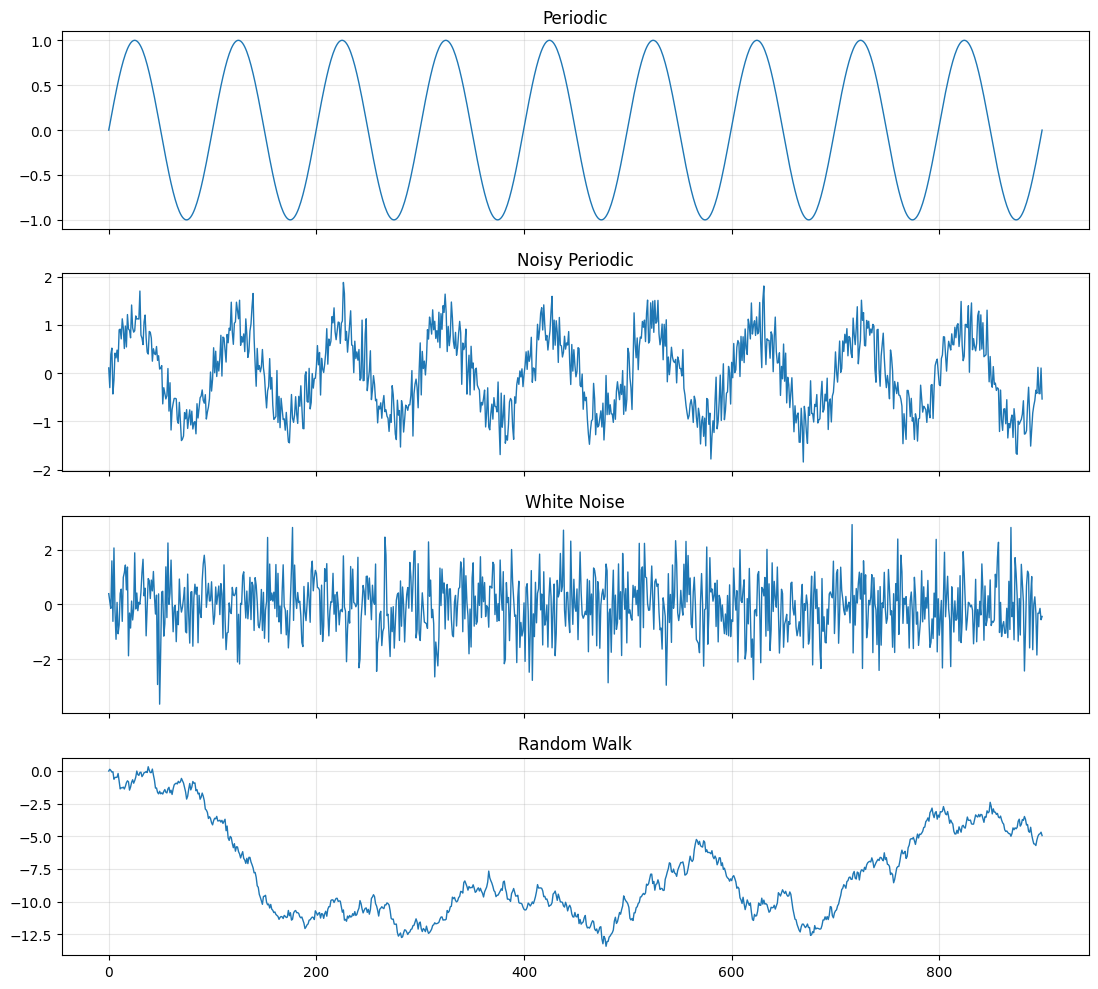

In [3]:
rng = np.random.default_rng(42)
n = 900
t = np.linspace(0.0, 18.0 * np.pi, n)

signals: dict[str, np.ndarray] = {
    "periodic": np.sin(t),
    "noisy_periodic": np.sin(t) + 0.35 * rng.normal(size=n),
    "white_noise": rng.normal(size=n),
    "random_walk": np.cumsum(0.3 * rng.normal(size=n)),
}

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for ax, (name, values) in zip(axes, signals.items()):
    ax.plot(values, linewidth=1.0)
    ax.set_title(name.replace("_", " ").title())
    ax.grid(alpha=0.3)
plt.tight_layout()

In [4]:
summary_rows: list[dict[str, float]] = []
for name, values in signals.items():
    summary_rows.append(
        {
            "signal": name,
            "mean": float(np.mean(values)),
            "variance": float(np.var(values)),
            "ApEn(scale=1)": float(approximate_entropy(values, m=2)),
            "SampEn(scale=1)": float(sample_entropy(values, m=2)),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values("SampEn(scale=1)")
summary_df

,signal,mean,variance,ApEn(scale=1),SampEn(scale=1)
0,periodic,-4.736952e-17,0.499444,0.210148,0.168372
3,random_walk,-7.846427e+00,12.437327,0.256634,0.243789
1,noisy_periodic,-1.534971e-02,0.612484,1.426646,1.543177
2,white_noise,-3.904235e-02,1.043975,1.613946,2.224770


Notice that mean and variance describe the amplitude distribution, not the temporal
organization. The entropy columns react to regularity and pattern stability.

In [5]:
scales = list(range(1, 21))

mse_frames = []
for name, values in signals.items():
    frame = multiscale_entropy(values, scales=scales, m=2, r_factor=0.2, method="sample")
    frame["signal"] = name
    mse_frames.append(frame)

mse_df = pd.concat(mse_frames, ignore_index=True)
mse_df.head()

,scale,length_after_coarse_graining,entropy,signal
0,1,900,0.168372,periodic
1,2,450,0.248594,periodic
2,3,300,0.239779,periodic
3,4,225,0.276253,periodic
4,5,180,0.324524,periodic


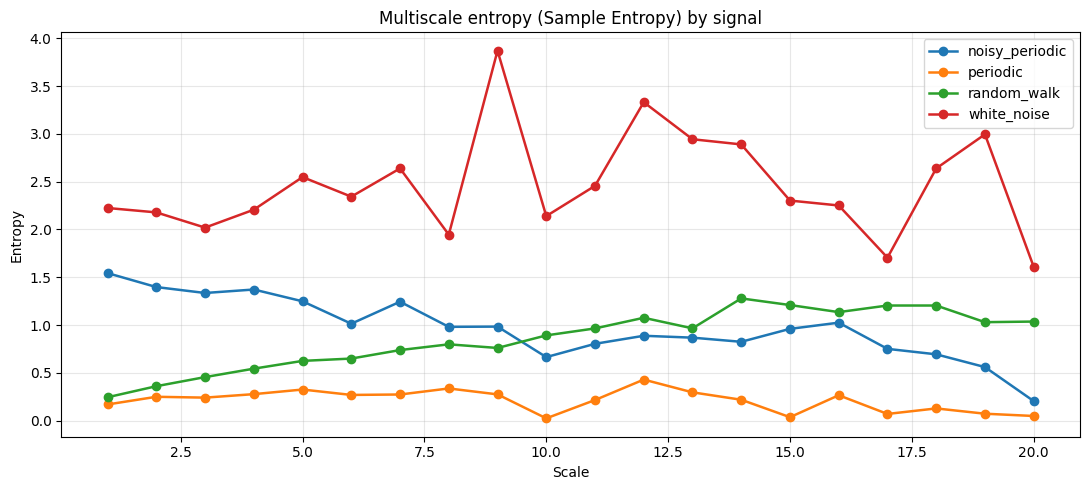

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, group in mse_df.groupby("signal"):
    ax.plot(group["scale"], group["entropy"], marker="o", linewidth=1.8, label=name)
ax.set_title("Multiscale entropy (Sample Entropy) by signal")
ax.set_xlabel("Scale")
ax.set_ylabel("Entropy")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

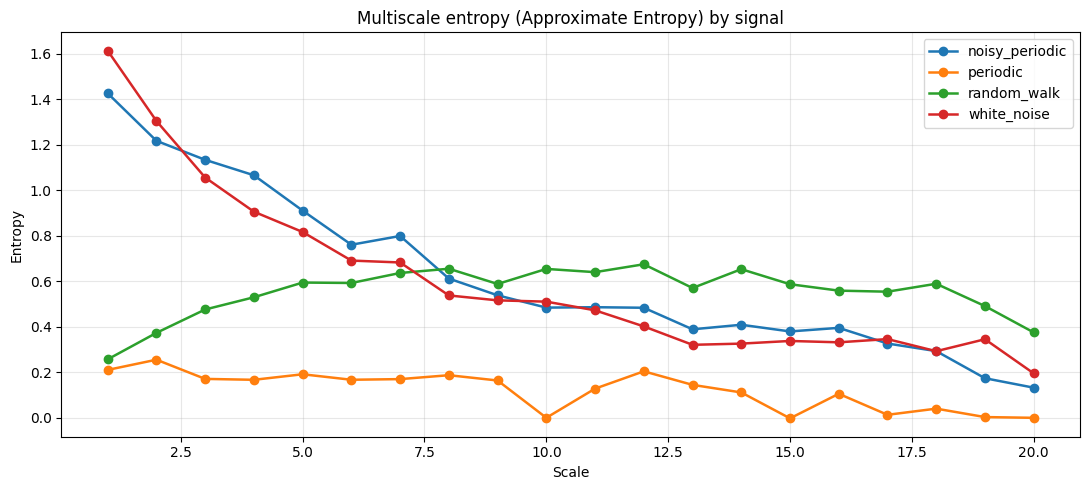

In [7]:
apen_scale_frames = []
for name, values in signals.items():
    frame = multiscale_entropy(values, scales=scales, m=2, r_factor=0.2, method="approximate")
    frame["signal"] = name
    apen_scale_frames.append(frame)

apen_mse_df = pd.concat(apen_scale_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 5))
for name, group in apen_mse_df.groupby("signal"):
    ax.plot(group["scale"], group["entropy"], marker="o", linewidth=1.8, label=name)
ax.set_title("Multiscale entropy (Approximate Entropy) by signal")
ax.set_xlabel("Scale")
ax.set_ylabel("Entropy")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()

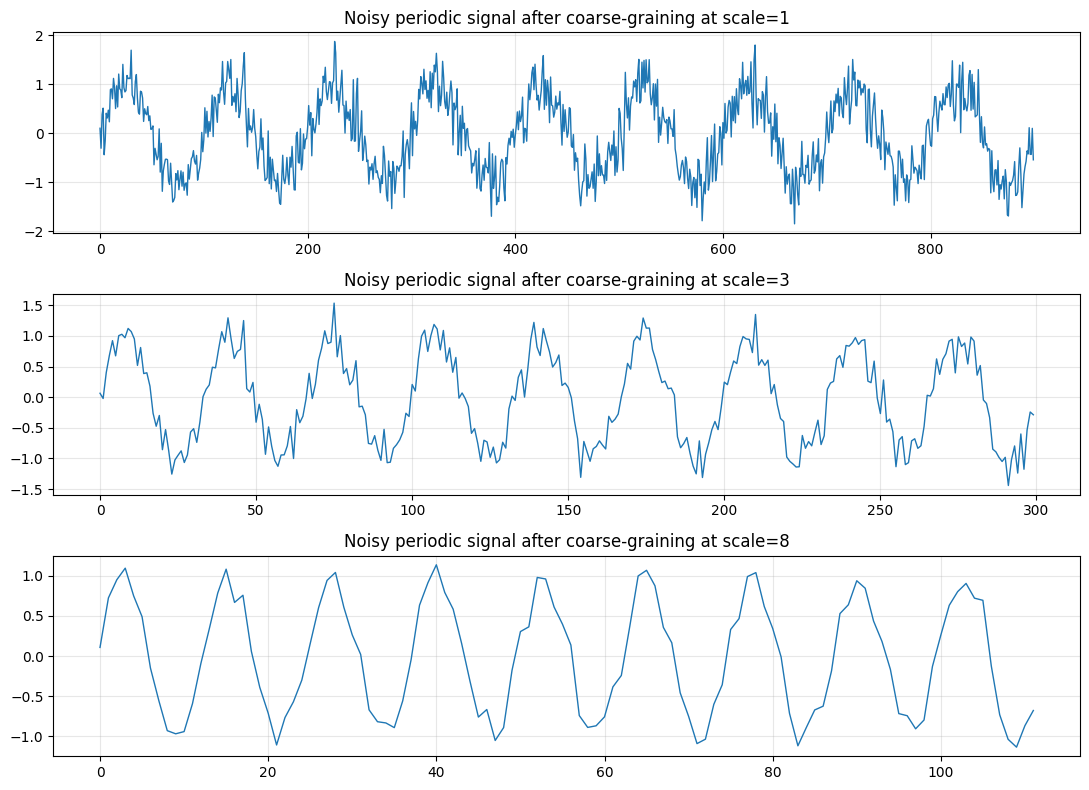

In [8]:
selected_scales = [1, 3, 8]

fig, axes = plt.subplots(len(selected_scales), 1, figsize=(11, 8), sharex=False)
for ax, scale in zip(axes, selected_scales):
    cg = coarse_grain(signals["noisy_periodic"], scale)
    ax.plot(cg, linewidth=1.0)
    ax.set_title(f"Noisy periodic signal after coarse-graining at scale={scale}")
    ax.grid(alpha=0.3)

plt.tight_layout()

## Interpretation

A few recurring patterns usually appear:

- Strongly periodic signals often keep relatively low entropy across scales.
- White noise tends to have higher entropy at fine scales, but coarse-graining can smooth it.
- Random walks are tricky: they are not white noise, and coarse-graining can reveal strong
  dependence that is hidden by short-scale fluctuations.

This is exactly why multiscale analysis is useful. One scalar summary is often too crude.

## Exercises and next steps

1. Replace the synthetic signals with your own telemetry or physiological series.
2. Compute the entropy on the **raw signal**, the **first difference**, and the **STL residual**.
3. Study how stable the conclusions are when `m` or `r_factor` change.
4. Compare ApEn-based multiscale curves with permutation entropy at the same scales.